# Applying Dimensionality Reduction to Real-World Datasets (Images and Text)

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply dimensionality reduction techniques to real-world image datasets
- Apply dimensionality reduction techniques to text data
- Compare PCA, SVD, and t-SNE on different data types
- Evaluate dimensionality reduction performance

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — real, messy tables; here the same realism meets image and text data.

**Used later in:** Course 07 (AIAT 121) — Unit 2, lesson 02 "Word Embeddings" — text turned into vectors, then projected down to be seen.

---

This notebook covers practical activities from **Course 03, Unit 4**:
- Writing code to apply dimensionality reduction techniques on real-world datasets including images and text data

---

## Introduction

**Dimensionality reduction** is crucial for handling high-dimensional real-world data. This notebook demonstrates applying PCA, SVD, and t-SNE to image and text datasets.


---

## 📌 Real case: the benchmark that classifies email headers instead of topics

The 20 Newsgroups corpus that this notebook loads has been a standard text benchmark since the mid-1990s,
and scikit-learn ships a warning with it that is worth reading before you trust any result built on it:
"It is easy for a classifier to overfit on particular things that appear in the 20 Newsgroups data, such as
newsgroup headers... their results would not generalize to other documents." The documentation demonstrates
it. A multinomial naive Bayes classifier on the full posts reaches an F-score of **0.882**. Strip the
headers, signature blocks and quoted text with `remove=('headers','footers','quotes')` and the same
classifier drops to **0.773**. The features it had been relying on include whether a `NNTP-Posting-Host:`
header appears, whether the sender's signature shows a university affiliation, and the names and e-mail
addresses of particular people who happened to post in 1993.

**Note what this notebook does**: it calls `fetch_20newsgroups(...)` **without** `remove=`. So some of the
structure you are about to see in the 2D text plot is topic — and some of it is 1993 email plumbing.

**What goes wrong without this.** Nothing visible. You get separated clusters, a good number, and a model
that collapses the moment it meets a document from outside that corpus and that decade. Every real dataset
has a version of this, and finding it is not a modelling task — it is a reading task.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: the full dimensionality-reduction toolkit (PCA, TruncatedSVD, t-SNE),
# TF-IDF text vectorization, and real datasets: digit images and 20 Newsgroups posts,
# with real 911 call descriptions held in reserve as an offline text fallback.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits, fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nApplying Dimensionality Reduction to Real-World Datasets")
print("=" * 60)

✅ Libraries imported!

Applying Dimensionality Reduction to Real-World Datasets


## Part 1: Dimensionality Reduction on Image Data


Part 1: Dimensionality Reduction on Image Data

Image dataset shape: (1797, 64)
Original dimension: 64 (8x8 pixels)
Number of samples: 1797

PCA reduced to: (1797, 2)
Variance explained: 0.2159

Applying t-SNE (this may take a minute)...


t-SNE reduced to: (1000, 2)


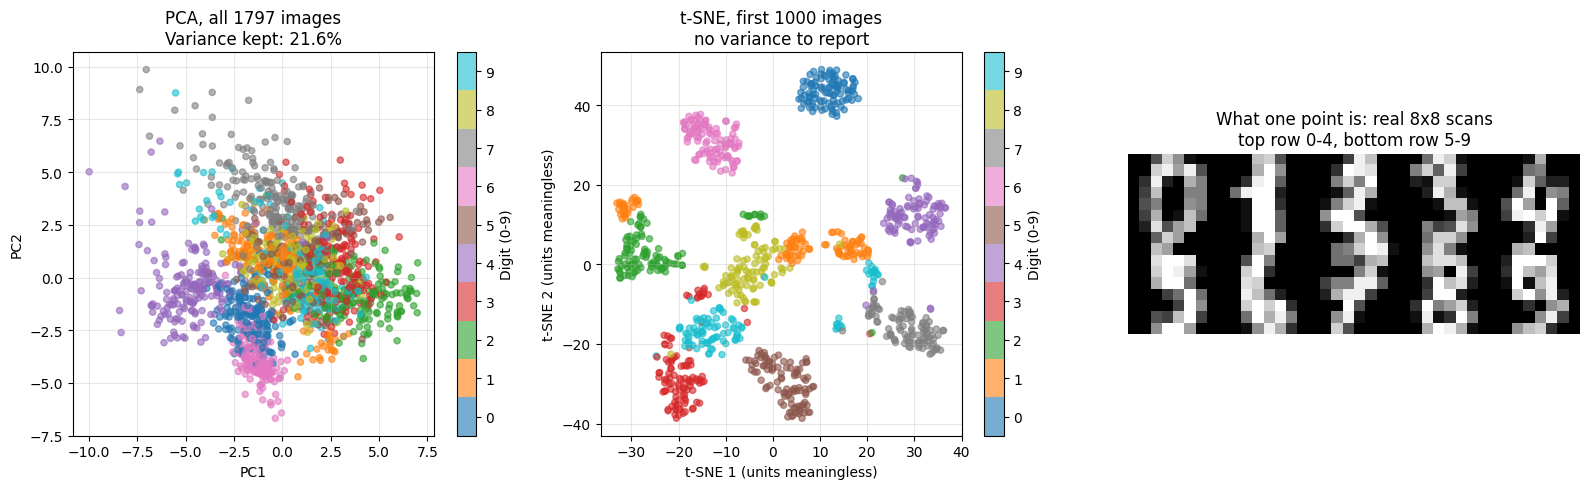


✅ Dimensionality reduction applied to image data!

Read the figure: LEFT, two principal components of the 64 pixels - the ten colours
   form overlapping lobes and only 21.6% of the variance survives, so the
   classes are visible but not separated. MIDDLE, t-SNE on the first 1000 of the same
   images pulls those lobes into detached islands - better to look at, but its axes carry
   no variance figure and its between-island gaps mean nothing. RIGHT, what a single dot
   in either panel actually is: one real 8x8 scan of somebody's handwriting.


In [2]:
# Real-world run #1 — images: standardize the 64-pixel digit vectors, then embed with PCA and t-SNE.
# The colored clusters answer a practical question: do raw pixels already separate the ten digits?

print("=" * 60)
print("Part 1: Dimensionality Reduction on Image Data")
print("=" * 60)

# Load digit images dataset
digits = load_digits()
X_images = digits.data
y_images = digits.target
images = digits.images

print(f"\nImage dataset shape: {X_images.shape}")
print(f"Original dimension: {X_images.shape[1]} (8x8 pixels)")
print(f"Number of samples: {X_images.shape[0]}")

# Standardize
scaler = StandardScaler()
X_images_scaled = scaler.fit_transform(X_images)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_images_scaled)
print(f"\nPCA reduced to: {X_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Apply t-SNE (takes longer)
print("\nApplying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_images_scaled[:1000])  # Use subset for speed
print(f"t-SNE reduced to: {X_tsne.shape}")

# Visualize
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_images, cmap='tab10', alpha=0.6, s=20)
scatter.set_clim(-0.5, 9.5)          # a digit is a CATEGORY: one colour band per class
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA, all {len(X_images)} images\nVariance kept: {pca.explained_variance_ratio_.sum():.1%}')
plt.colorbar(scatter, ticks=range(10), label='Digit (0-9)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_images[:1000], cmap='tab10', alpha=0.6, s=20)
scatter.set_clim(-0.5, 9.5)
plt.xlabel('t-SNE 1 (units meaningless)')
plt.ylabel('t-SNE 2 (units meaningless)')
plt.title('t-SNE, first 1000 images\nno variance to report')
plt.colorbar(scatter, ticks=range(10), label='Digit (0-9)')
plt.grid(True, alpha=0.3)

# Show what the coloured dots actually ARE: one real scan of each digit 0-9, laid out
# 2 x 5 so the grid is full (the old 3 x 4 layout left two black holes in the corner).
plt.subplot(1, 3, 3)
sample_indices = [int(np.where(y_images == d)[0][0]) for d in range(10)]
fig_grid = np.zeros((8 * 2, 8 * 5))
for i, idx in enumerate(sample_indices):
    row, col = (i // 5) * 8, (i % 5) * 8
    fig_grid[row:row + 8, col:col + 8] = images[idx]
plt.imshow(fig_grid, cmap='gray')
plt.title('What one point is: real 8x8 scans\ntop row 0-4, bottom row 5-9')
plt.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Dimensionality reduction applied to image data!")
print("\nRead the figure: LEFT, two principal components of the 64 pixels - the ten colours")
print(f"   form overlapping lobes and only {pca.explained_variance_ratio_.sum():.1%} of the variance survives, so the")
print("   classes are visible but not separated. MIDDLE, t-SNE on the first 1000 of the same")
print("   images pulls those lobes into detached islands - better to look at, but its axes carry")
print("   no variance figure and its between-island gaps mean nothing. RIGHT, what a single dot")
print("   in either panel actually is: one real 8x8 scan of somebody's handwriting.")

**Read the figure above.** Three views of the same 1,797 real handwritten digits.
**Left — PCA on all of them**: the ten colours form overlapping lobes rather than separate groups, which is
what keeping **21.6% of the variance** in two components buys you; you can see 0 (blue) and 6 (pink) pull
to the bottom and 4 (purple) to the left, but the middle is a single mixed mass. **Middle — t-SNE on the
first 1,000**: the same classes become detached islands, far easier to look at — but its axes carry no
variance figure at all, and the gaps between islands are not distances you may interpret. **Right — what a
single dot in either panel actually is**: one real 8×8 scan of somebody's handwriting, 0–4 along the top
row and 5–9 along the bottom. Sixty-four grey numbers per dot, squeezed down to two.

## Part 2: Dimensionality Reduction on Text Data



Part 2: Dimensionality Reduction on Text Data

Loading 20 Newsgroups dataset...
Loaded 500 text documents
Categories: {'sci.space', 'alt.atheism', 'rec.autos'}

Converting text to TF-IDF vectors...


TF-IDF matrix shape: (500, 1000)
High-dimensional text representation: 1000 features

SVD reduced to: (500, 2)
Variance explained: 0.0243


PCA reduced to: (500, 2)
Variance explained: 0.0378



5-fold accuracy on the raw posts:            95.4%
5-fold accuracy with headers/footers/quotes stripped: 79.2%


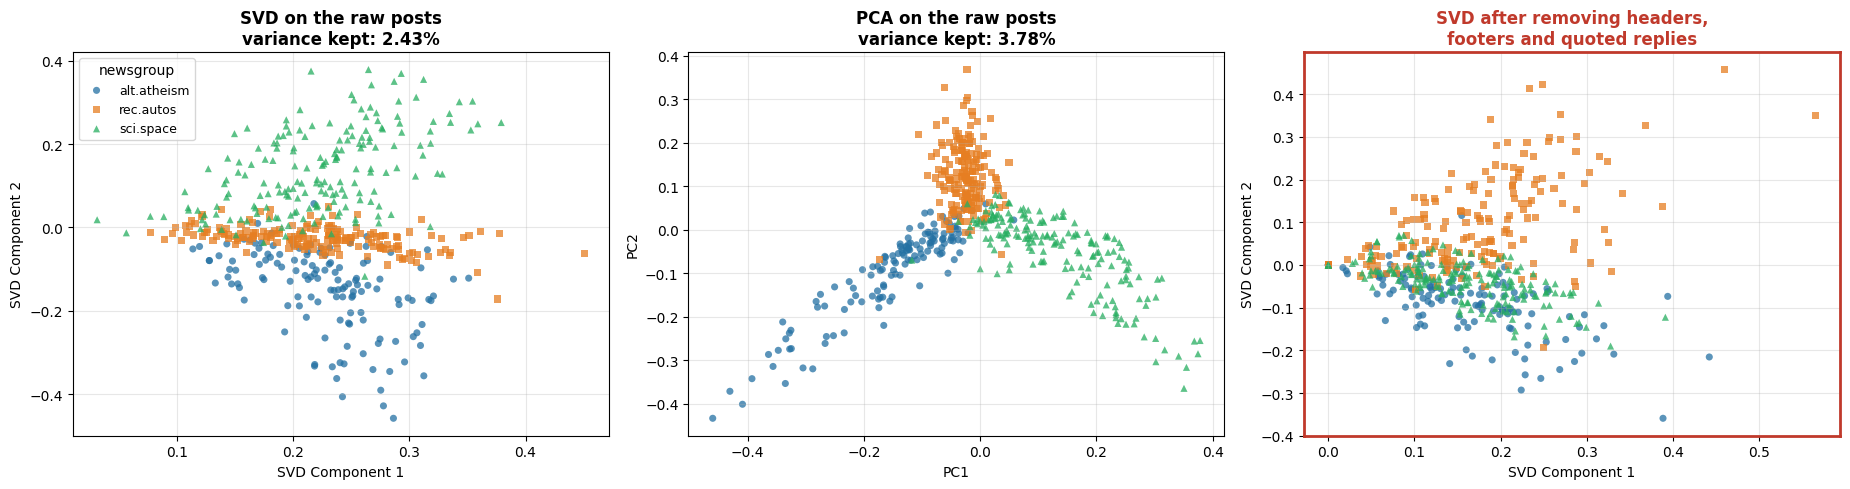


✅ Dimensionality reduction applied to text data!

Read the figure: the LEFT and MIDDLE panels are the same 500 raw posts through two
   linear lenses, and both show visible topic structure even though they keep only
   2.4% and 3.8% of the variance - proof that 'variance explained' is a poor
   summary for sparse text. The RIGHT panel (red frame) is the honest control: the same
   corpus with headers, footers and quoted replies stripped out. The three groups smear
   into each other, and the classifier drops from 95.4% to 79.2%. Roughly
   16 points of that 'topic separation' was e-mail plumbing, not topic.


In [3]:
# Real-world run #2 — text: TF-IDF turns 500 newsgroup posts into 1000-dim sparse vectors,
# then SVD (sparse-friendly) and PCA compress them to 2D. Topic clusters emerge without labels.

print("\n" + "=" * 60)
print("Part 2: Dimensionality Reduction on Text Data")
print("=" * 60)

# Load text dataset
print("\nLoading 20 Newsgroups dataset...")
try:
    newsgroups = fetch_20newsgroups(subset='train', categories=['alt.atheism', 'sci.space', 'rec.autos'], 
                                    shuffle=True, random_state=42)
    texts = newsgroups.data[:500]  # Use subset
    labels = newsgroups.target[:500]
    category_names = [newsgroups.target_names[i] for i in labels]
    used_newsgroups = True
    print(f"Loaded {len(texts)} text documents")
    print(f"Categories: {set(category_names)}")
except Exception as err:
    # Fall back to REAL text held locally, never to invented sentences: the free-text
    # descriptions attached to Montgomery County 911 calls, labelled by call category.
    print(f"20 Newsgroups unavailable ({type(err).__name__}); using real 911 call descriptions instead.")
    calls = pd.read_csv(data_path("montgomery_911_calls.csv"),
                        usecols=["title", "desc"], nrows=20000)
    calls["category"] = calls["title"].str.split(":").str[0]
    calls = calls[calls["category"].isin(["EMS", "Fire", "Traffic"])]
    calls = calls.sample(n=500, random_state=42)
    texts = calls["desc"].astype(str).tolist()
    category_names = calls["category"].tolist()
    codes, uniques = pd.factorize(calls["category"])
    labels = np.asarray(codes)
    used_newsgroups = False
    print(f"Loaded {len(texts)} real 911 call descriptions")
    print(f"Categories: {set(category_names)}")

# Convert text to TF-IDF vectors
print("\nConverting text to TF-IDF vectors...")
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', max_df=0.95, min_df=2)
X_text = vectorizer.fit_transform(texts)
print(f"TF-IDF matrix shape: {X_text.shape}")
print(f"High-dimensional text representation: {X_text.shape[1]} features")

# Apply SVD (works with sparse matrices)
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_text)
print(f"\nSVD reduced to: {X_svd.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.4f}")

# Apply PCA (needs dense matrix, so use SVD first for efficiency)
pca_text = PCA(n_components=2)
X_text_dense = X_text.toarray()  # Convert to dense (may be memory intensive)
X_pca_text = pca_text.fit_transform(X_text_dense)
print(f"PCA reduced to: {X_pca_text.shape}")
print(f"Variance explained: {pca_text.explained_variance_ratio_.sum():.4f}")

# This notebook's own "Where this breaks" section says the most informative experiment here
# is to strip the headers, footers and quoted replies and see how much topic structure is
# left. That is a claim about a DIFFERENCE, so it needs the two pictures side by side.
X_svd_clean = None
if used_newsgroups:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score

    clean = fetch_20newsgroups(subset='train',
                               categories=['alt.atheism', 'sci.space', 'rec.autos'],
                               shuffle=True, random_state=42,
                               remove=('headers', 'footers', 'quotes'))
    texts_clean = clean.data[:500]
    labels_clean = clean.target[:500]
    X_text_clean = TfidfVectorizer(max_features=1000, stop_words='english',
                                   max_df=0.95, min_df=2).fit_transform(texts_clean)
    X_svd_clean = TruncatedSVD(n_components=2, random_state=42).fit_transform(X_text_clean)
    # How much of the "topic signal" was really header leakage? Measure the same classifier
    # on the same 500 posts, before and after the strip.
    acc_raw = cross_val_score(LogisticRegression(max_iter=2000), X_text, labels, cv=5).mean()
    acc_clean = cross_val_score(LogisticRegression(max_iter=2000), X_text_clean, labels_clean,
                                cv=5).mean()
    print(f"\n5-fold accuracy on the raw posts:            {acc_raw:.1%}")
    print(f"5-fold accuracy with headers/footers/quotes stripped: {acc_clean:.1%}")

# Visualize. One colour + marker per NAMED category: 'category = 1.25' is not a thing,
# so the continuous colour bar this cell used to draw was meaningless.
names = sorted(set(category_names))
styles = list(zip(names, ['#2471a3', '#e67e22', '#27ae60'], ['o', 's', '^']))
label_of = {name: i for i, name in enumerate(newsgroups.target_names)} if used_newsgroups else None


def draw_categories(ax, Z, lab):
    for name, colour, marker in styles:
        code = label_of[name] if label_of is not None else names.index(name)
        m = np.asarray(lab) == code
        ax.scatter(Z[m, 0], Z[m, 1], c=colour, marker=marker, s=26, alpha=0.75,
                   edgecolors='none', label=name)


n_panels = 3 if X_svd_clean is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6.2 * n_panels, 5))

draw_categories(axes[0], X_svd, labels)
axes[0].set_xlabel('SVD Component 1'); axes[0].set_ylabel('SVD Component 2')
axes[0].set_title(f'SVD on the raw posts\nvariance kept: {svd.explained_variance_ratio_.sum():.2%}',
                  fontsize=12, fontweight='bold')
axes[0].legend(title='newsgroup', fontsize=9)
axes[0].grid(True, alpha=0.3)

draw_categories(axes[1], X_pca_text, labels)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title(f'PCA on the raw posts\nvariance kept: {pca_text.explained_variance_ratio_.sum():.2%}',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

if X_svd_clean is not None:
    draw_categories(axes[2], X_svd_clean, labels_clean)
    axes[2].set_xlabel('SVD Component 1'); axes[2].set_ylabel('SVD Component 2')
    axes[2].set_title('SVD after removing headers,\nfooters and quoted replies',
                      fontsize=12, fontweight='bold', color='#c0392b')
    axes[2].grid(True, alpha=0.3)
    for spine in axes[2].spines.values():
        spine.set_edgecolor('#c0392b'); spine.set_linewidth(2)

plt.tight_layout()
plt.show()

print("\n✅ Dimensionality reduction applied to text data!")
if X_svd_clean is not None:
    print("\nRead the figure: the LEFT and MIDDLE panels are the same 500 raw posts through two")
    print("   linear lenses, and both show visible topic structure even though they keep only")
    print(f"   {svd.explained_variance_ratio_.sum():.1%} and {pca_text.explained_variance_ratio_.sum():.1%} of the variance - proof that 'variance explained' is a poor")
    print("   summary for sparse text. The RIGHT panel (red frame) is the honest control: the same")
    print("   corpus with headers, footers and quoted replies stripped out. The three groups smear")
    print(f"   into each other, and the classifier drops from {acc_raw:.1%} to {acc_clean:.1%}. Roughly")
    print(f"   {100 * (acc_raw - acc_clean):.0f} points of that 'topic separation' was e-mail plumbing, not topic.")

**Read the figure above.** **Left and middle**: the same 500 newsgroup posts, as 1,000
TF-IDF term dimensions, reduced to 2-D by SVD and by PCA. Both show real topic structure — in the SVD panel
`sci.space` (green triangles) sits above `rec.autos` (orange squares) which sits above `alt.atheism` (blue
circles) — while keeping only **2.43%** and **3.78%** of the variance. Both facts are true at once, which
is precisely why "variance explained" is a bad summary for sparse text.

**Right, in the red frame — the control this notebook's own warning asks for.** Same posts, same
vectorizer, same SVD, but with `remove=('headers','footers','quotes')`. The clean separation collapses:
`sci.space` (green) contracts into a dense clump against the left edge, sitting directly on top of
`alt.atheism` (blue); `rec.autos` (orange) still holds the upper right, but its own boundary is no longer
clean. The number underneath says the same thing: a linear classifier on these posts scores **95.4%** raw and
**79.2%** stripped. About **16 points** of the apparent "topic signal" was e-mail plumbing — sender
addresses, signatures and quoted replies — not subject matter. Always run this control before believing a
text projection.

---

## ⚠️ Where this breaks

- **"Variance explained" is almost meaningless for sparse text, and the printout shows it.** SVD to 2
  components explains **2.43%** of the variance of the TF-IDF matrix; PCA explains **3.78%**. Yet the plot
  shows visible topic structure. Both facts are true: with 1,000 sparse term dimensions the variance is
  spread almost evenly, so the ratio is a bad summary of whether the projection is useful. Judge a text
  embedding by a downstream task, not by explained variance.
- **The clusters are partly an artefact of the corpus, and the third panel proves it.** Raw newsgroup
  posts carry headers, signatures and quoted replies, and those leak the answer. The figure above runs the
  control: with `remove=('headers','footers','quotes')` the three groups smear together, and a linear
  classifier on the same 500 posts falls from **95.4%** to **79.2%**. About sixteen points of what looked
  like "topics separating" was e-mail plumbing. The projection was never wrong — it was faithfully showing
  structure that had nothing to do with the topic. Run this control before believing any text embedding.
- **The two runs are not comparable, and should not be compared.** Part 1 standardizes 64 dense pixel
  features; Part 2 uses 1,000 sparse TF-IDF features and deliberately does *not* centre them, because
  centring a sparse matrix destroys the sparsity that made it affordable. That is why `TruncatedSVD` exists
  alongside `PCA`. Any statement of the form "PCA did better on images than on text" is comparing two
  different procedures on two different data types with two different preprocessing steps.
- **t-SNE was run on 1,000 of the 1,797 images for speed.** The subset is not random with respect to
  anything in particular, but it is a subset, and the embedding would look different for another one.


---

## 💬 Discuss

1. Removing headers and quotes costs the benchmark classifier 11 F-score points. Is the higher number
   *wrong*, or is it correct for a question nobody wanted answered? What does that distinction mean for
   how you read leaderboards?
2. Two components explain 2.4% of the variance in the text data and the plot still shows structure. What
   does that tell you about using explained variance to choose the number of components for sparse data —
   and what would you use instead?
3. You are asked to build a topic clustering for Arabic customer-support tickets from a Saudi telecom.
   Name three "header-like" leaks that could appear in that data — things that separate the classes for
   reasons that have nothing to do with the topic — and say how you would detect each one.


## Summary

### Key Concepts:
1. **Image Data**: High-dimensional pixel vectors, benefit from PCA/t-SNE
2. **Text Data**: High-dimensional TF-IDF vectors, benefit from SVD/PCA
3. **PCA**: Linear, preserves global structure, works on dense matrices
4. **SVD**: Linear, works on sparse matrices (good for text)
5. **t-SNE**: Non-linear, preserves local structure, good for visualization

### Best Practices:
- Standardize data before PCA
- Use SVD for sparse matrices (text data)
- Use t-SNE for visualization (may be slow)
- Consider variance explained when selecting components
- Evaluate based on downstream task performance

### Applications:
- Image compression and visualization
- Text document clustering
- Feature extraction for ML models
- Data exploration and visualization

**Reference:** Course 03, Unit 4: "Dimensionality Reduction" - Real-world datasets practical content

## 📚 References

1. Hotelling, H. (1933). *Analysis of a Complex of Statistical Variables into Principal Components*. Journal of Educational Psychology, 24, 417–441.
2. van der Maaten, L., & Hinton, G. (2008). *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579–2605. <https://jmlr.org/papers/v9/vandermaaten08a.html>
3. McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*. arXiv. <https://arxiv.org/abs/1802.03426>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 12: Unsupervised Learning. Springer. <https://www.statlearning.com/>
5. Zhang et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. arXiv. <https://arxiv.org/abs/2506.05176> — what replaced TF-IDF as the first step for real text before any reduction happens.
6. Enevoldsen, K., Chung, I., Kerboua, I., Kardos, M., Mathur, A., et al. (2025). *MMTEB: Massive Multilingual Text Embedding Benchmark*. arXiv. <https://arxiv.org/abs/2502.13595> — evidence for choosing that encoder, including for non-English corpora.
